# 📊 Regresi Linier (Linear Regression)

## 1. Apa itu Regresi Linier?

Regresi Linier adalah metode **supervised learning** untuk memprediksi nilai **kontinu** (bukan kategori).
Dalam peta machine learning:

| | Kontinu | Kategorikal |
|---|---|---|
| **Supervised** | **Regression** ✅ | Classification |
| **Unsupervised** | Dimension Reduction | Clustering |

### Mengapa penting dipelajari?
- Banyak digunakan di industri dan akademik
- Komputasi cepat
- Mudah digunakan (tidak perlu banyak tuning)
- Sangat interpretable (mudah dijelaskan)
- Menjadi dasar banyak metode lainnya

---

## 2. Model Regresi Linier Sederhana

$$y = \beta_0 + \beta_1 x + \varepsilon$$

| Simbol | Nama | Keterangan |
|--------|------|------------|
| $y$ | Response variable | Nilai yang ingin diprediksi |
| $x$ | Input variable | Variabel prediktor/fitur |
| $\beta_0$ | Intercept | Titik potong garis dengan sumbu-y |
| $\beta_1$ | Regression coefficient | Kemiringan garis ($\Delta y / \Delta x$) |
| $\varepsilon$ | Residual | Error / selisih prediksi dengan data asli |

---

## 3. Model Regresi Linier Berganda (Multiple)

Untuk beberapa variabel input:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \varepsilon$$

---

## 4. Estimasi Koefisien

### Konsep: Meminimalkan Sum of Squared Residuals (SSR)

$$SS_{residuals} = \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

Kita mencari garis yang meminimalkan jumlah kuadrat error antara nilai prediksi $\hat{y}$ dan nilai aktual $y$.

### Rumus Analitik (Ordinary Least Squares / OLS)

$$\boxed{\hat{\beta} = (X^T X)^{-1} X^T Y}$$

Di mana:
- $X$ = Matriks fitur (dengan kolom pertama berisi angka 1 sebagai bias/intercept)
- $Y$ = Vektor target / response
- $X^T$ = Transpose dari matriks $X$
- $(X^T X)^{-1}$ = Invers dari matriks $(X^T X)$

---

## 5. Contoh Perhitungan Manual

### Dataset

| Observasi | X (Prediktor) | Y (Target) |
|-----------|--------------|------------|
| 1 | 3.385 | 44.5 |
| 2 | 0.48 | 15.5 |
| 3 | 1.35 | 8.1 |
| 4 | 465.0 | 423.0 |
| 5 | 36.33 | 119.5 |

### Langkah 1: Susun Matriks X dan Y

$$X = \begin{pmatrix} 1 & 3.385 \\ 1 & 0.48 \\ 1 & 1.35 \\ 1 & 465 \\ 1 & 36.33 \end{pmatrix}, \quad Y = \begin{pmatrix} 44.5 \\ 15.5 \\ 8.1 \\ 423 \\ 119.5 \end{pmatrix}$$

> Kolom pertama berisi angka 1 sebagai placeholder untuk intercept $\beta_0$.

### Langkah 2: Hitung $X^T X$

$$X^T X = \begin{pmatrix} 5 & 506.54 \\ 506.54 & 217558.38 \end{pmatrix}$$

### Langkah 3: Hitung $(X^T X)^{-1}$

Invers matriks 2×2: tukar diagonal, bagi dengan determinan.

$$det = 5 \times 217558.38 - 506.54 \times 506.54$$

$$(X^T X)^{-1} = \begin{pmatrix} 0.26 & -6.1 \times 10^{-4} \\ -6.1 \times 10^{-4} & 6.0 \times 10^{-6} \end{pmatrix}$$

### Langkah 4: Hitung $X^T Y$

$$X^T Y = \begin{pmatrix} 610.6 \\ 201205.4 \end{pmatrix}$$

### Langkah 5: Hitung $\hat{\beta}$

$$\begin{pmatrix} \hat{\beta}_0 \\ \hat{\beta}_1 \end{pmatrix} = \begin{pmatrix} 0.26 & -6.1 \times 10^{-4} \\ -6.1 \times 10^{-4} & 6.0 \times 10^{-6} \end{pmatrix} \begin{pmatrix} 610.6 \\ 201205.4 \end{pmatrix} = \begin{pmatrix} 37.201 \\ 0.838 \end{pmatrix}$$

**Hasil:** $\hat{y} = 37.201 + 0.838 \cdot x$

---

## 6. Variabel Kategorikal (Dummy Variables)

Untuk variabel kategorikal dengan $k$ level, buat $k-1$ variabel binary (dummy).

**Contoh:** Variabel `Major` dengan $k=4$ (CS, Engineering, Business, Literature)

| Major | Engineering | Business | Literature |
|-------|-------------|----------|------------|
| Computer Science | 0 | 0 | 0 |
| Engineering | 1 | 0 | 0 |
| Business | 0 | 1 | 0 |
| Literature | 0 | 0 | 1 |

> "Computer Science" menjadi **referensi** (semua 0).
> Kenapa $k-1$? Untuk menghindari **multicollinearity** (korelasi sempurna antar prediktor).

**Tipe data kategorikal:**
- **Nominal** (tidak berurutan): gunakan dummy variables
- **Ordinal** (berurutan, mis. skala Likert): bisa dikodekan sebagai integer 1, 2, 3, 4, 5

---

## 7. Code Python

### 7.1 Menggunakan Sklearn (LinearRegression)

Intercept (β₀): 37.2009
Koefisien (β₁): 0.8382


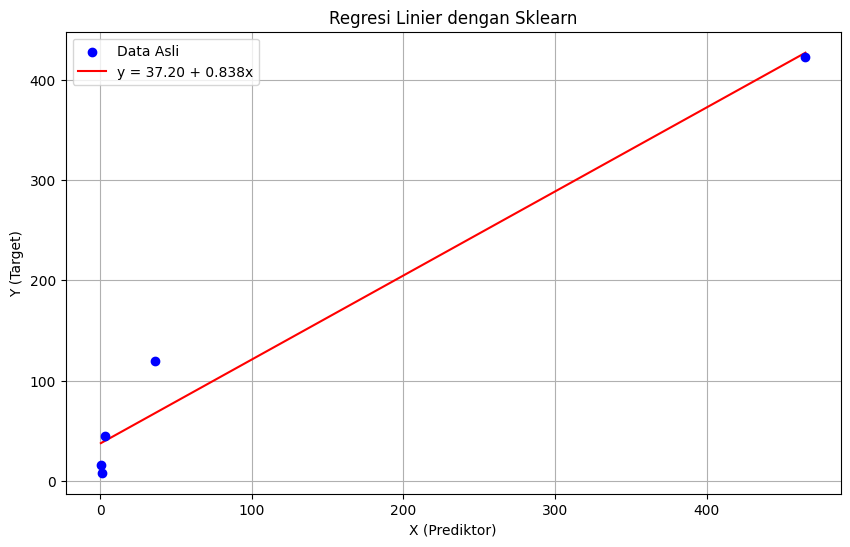

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Dataset
X = np.array([3.385, 0.48, 1.35, 465.0, 36.33]).reshape(-1, 1)
Y = np.array([44.5, 15.5, 8.1, 423.0, 119.5])

# Membuat dan melatih model
model = LinearRegression()
model.fit(X, Y)

# Koefisien hasil
print(f"Intercept (β₀): {model.intercept_:.4f}")
print(f"Koefisien (β₁): {model.coef_[0]:.4f}")

# Prediksi
X_pred = np.linspace(min(X), max(X), 100).reshape(-1, 1)
Y_pred = model.predict(X_pred)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data Asli', zorder=5)
plt.plot(X_pred, Y_pred, color='red', label=f'y = {model.intercept_:.2f} + {model.coef_[0]:.3f}x')
plt.xlabel('X (Prediktor)')
plt.ylabel('Y (Target)')
plt.title('Regresi Linier dengan Sklearn')
plt.legend()
plt.grid(True)
plt.show()

### 7.2 Perhitungan Analitik OLS (Tanpa Library)

In [2]:
import numpy as np

# Dataset
X_raw = np.array([3.385, 0.48, 1.35, 465.0, 36.33])
Y = np.array([44.5, 15.5, 8.1, 423.0, 119.5])

# Tambahkan kolom 1 untuk intercept
ones = np.ones((len(X_raw), 1))
X = np.column_stack([ones, X_raw])

print("Matriks X:")
print(X)

# Hitung X^T X
XTX = X.T @ X
print("\nX^T X:")
print(XTX)

# Hitung (X^T X)^-1
XTX_inv = np.linalg.inv(XTX)
print("\n(X^T X)^-1:")
print(XTX_inv)

# Hitung X^T Y
XTY = X.T @ Y
print("\nX^T Y:")
print(XTY)

# Hitung beta = (X^T X)^-1 X^T Y
beta = XTX_inv @ XTY
print("\nKoefisien β:")
print(f"  β₀ (intercept) = {beta[0]:.4f}")
print(f"  β₁ (slope)     = {beta[1]:.4f}")

# Prediksi
Y_hat = X @ beta
print("\nPrediksi vs Aktual:")
for i in range(len(Y)):
    print(f"  X={X_raw[i]:7.3f} | Y_aktual={Y[i]:6.1f} | Y_prediksi={Y_hat[i]:7.3f} | error={Y[i]-Y_hat[i]:+.3f}")

# Evaluasi: R-squared
SS_res = np.sum((Y - Y_hat) ** 2)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)
R2 = 1 - SS_res / SS_tot
print(f"\nR² Score: {R2:.4f}")

Matriks X:
[[  1.      3.385]
 [  1.      0.48 ]
 [  1.      1.35 ]
 [  1.    465.   ]
 [  1.     36.33 ]]

X^T X:
[[5.0000000e+00 5.0654500e+02]
 [5.0654500e+02 2.1755838e+05]]

(X^T X)^-1:
[[ 2.61738831e-01 -6.09411121e-04]
 [-6.09411121e-04  6.01537002e-06]]

X^T Y:
[   610.6    201205.4425]

Koefisien β:
  β₀ (intercept) = 37.2009
  β₁ (slope)     = 0.8382

Prediksi vs Aktual:
  X=  3.385 | Y_aktual=  44.5 | Y_prediksi= 40.038 | error=+4.462
  X=  0.480 | Y_aktual=  15.5 | Y_prediksi= 37.603 | error=-22.103
  X=  1.350 | Y_aktual=   8.1 | Y_prediksi= 38.332 | error=-30.232
  X=465.000 | Y_aktual= 423.0 | Y_prediksi=426.973 | error=-3.973
  X= 36.330 | Y_aktual= 119.5 | Y_prediksi= 67.653 | error=+51.847

R² Score: 0.9659


### 7.3 Regresi Linier Berganda (Multiple)

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Contoh dataset dengan 2 prediktor
np.random.seed(42)
n = 100
X1 = np.random.randn(n)
X2 = np.random.randn(n)
Y  = 3 + 2*X1 + 5*X2 + np.random.randn(n) * 0.5

X = np.column_stack([X1, X2])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
print(f"β₀ (intercept): {model.intercept_:.4f}")
print(f"β₁ (X1):        {model.coef_[0]:.4f}")
print(f"β₂ (X2):        {model.coef_[1]:.4f}")
print(f"MSE:            {mean_squared_error(y_test, y_pred):.4f}")
print(f"R² Score:       {r2_score(y_test, y_pred):.4f}")

β₀ (intercept): 3.0532
β₁ (X1):        2.0895
β₂ (X2):        5.0136
MSE:            0.1362
R² Score:       0.9940


### 7.4 Menangani Variabel Kategorikal dengan Pandas

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Dataset dengan kolom kategorikal
data = pd.DataFrame({
    'Major': ['CS', 'Engineering', 'Business', 'Literature', 'Business', 'Engineering'],
    'GPA': [3.8, 3.5, 3.2, 3.6, 3.0, 3.7],
    'Salary': [95000, 88000, 75000, 70000, 72000, 90000]
})

# One-hot encoding (k-1 dummy variables, drop_first=True)
data_encoded = pd.get_dummies(data, columns=['Major'], drop_first=True)
print(data_encoded)

X = data_encoded.drop('Salary', axis=1)
y = data_encoded['Salary']

model = LinearRegression()
model.fit(X, y)
print(f"\nIntercept: {model.intercept_:.2f}")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")

   GPA  Salary  Major_CS  Major_Engineering  Major_Literature
0  3.8   95000      True              False             False
1  3.5   88000     False               True             False
2  3.2   75000     False              False             False
3  3.6   70000     False              False              True
4  3.0   72000     False              False             False
5  3.7   90000     False               True             False

Intercept: 34750.00
GPA: 12500.00
Major_CS: 12750.00
Major_Engineering: 9250.00
Major_Literature: -9750.00


---

## 8. Visualisasi di GeoGebra

### Link GeoGebra
🔗 **[Buka GeoGebra Linear Regression](https://www.geogebra.org/m/xC6zq7Zv)**

Atau buat sendiri di: [https://www.geogebra.org/classic](https://www.geogebra.org/classic)

---

### Cara Membuat Regresi Linier di GeoGebra Classic

#### Langkah 1: Input Data sebagai List

Masukkan perintah berikut di **Input Bar** (baris bawah):

```
# Daftar titik data
X_data = {3.385, 0.48, 1.35, 465, 36.33}
Y_data = {44.5, 15.5, 8.1, 423, 119.5}
```

#### Langkah 2: Buat Titik-Titik

```
# Buat list titik
titik = Zip((x, y), x, X_data, y, Y_data)
```

Atau input manual tiap titik:

```
A = (3.385, 44.5)
B = (0.48, 15.5)
C = (1.35, 8.1)
D = (465, 423)
E = (36.33, 119.5)
```

#### Langkah 3: Hitung Garis Regresi Otomatis

```
# Regresi linier otomatis dari list titik
garis = FitLine({A, B, C, D, E})
```

GeoGebra akan menampilkan persamaan garis regresi secara otomatis!

#### Langkah 4: Formula Manual OLS (opsional, untuk verifikasi)

Hitung komponen OLS secara manual di GeoGebra:

```
# Jumlah data
n = 5

# Mean
x_bar = Mean(X_data)
y_bar = Mean(Y_data)

# Komponen regresi
Sxx = Sum(Zip((x - x_bar)^2, x, X_data))
Sxy = Sum(Zip((x - x_bar) * (y - y_bar), x, X_data, y, Y_data))

# Koefisien
beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar

# Tampilkan persamaan
persamaan = "y = " + beta0 + " + " + beta1 + "x"
```

#### Langkah 5: Visualisasi Residual

```
# Gambar residual (garis dari titik ke garis regresi)
residual_A = Segment(A, (x(A), beta0 + beta1 * x(A)))
residual_B = Segment(B, (x(B), beta0 + beta1 * x(B)))
residual_C = Segment(C, (x(C), beta0 + beta1 * x(C)))
residual_D = Segment(D, (x(D), beta0 + beta1 * x(D)))
residual_E = Segment(E, (x(E), beta0 + beta1 * x(E)))
```

#### Langkah 6: Hitung R² di GeoGebra

```
# Y prediksi
Y_hat = Map(beta0 + beta1 * x, X_data)

# SS_residuals dan SS_total
SS_res = Sum(Zip((y - yhat)^2, y, Y_data, yhat, Y_hat))
SS_tot = Sum(Zip((y - y_bar)^2, y, Y_data))

# R-squared
R2 = 1 - SS_res / SS_tot
```

---

## 9. Ringkasan Rumus Penting

| Rumus | Keterangan |
|-------|------------|
| $\hat{\beta} = (X^T X)^{-1} X^T Y$ | OLS estimator koefisien |
| $SS_{res} = \sum (\hat{y}_i - y_i)^2$ | Sum of Squared Residuals |
| $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$ | Koefisien determinasi |
| $\beta_1 = \frac{S_{xy}}{S_{xx}}$ | Slope (regresi sederhana) |
| $\beta_0 = \bar{y} - \beta_1 \bar{x}$ | Intercept (regresi sederhana) |

---

*Referensi: Slide Linear Regression — Supervised Learning*